## ERDDAP + xarray Integration (Basic Example)

This notebook demonstrates how to work with oceanographic-style datasets using xarray, inspired by ERDDAP workflows.

Since remote ERDDAP servers may not always be accessible, we simulate a dataset with the same structure typically returned by ERDDAP.

## Objectives

- Understand xarray Dataset structure
- Simulate ERDDAP-like data
- Perform basic analysis
- Visualize results

This example is relevant for the erddapy xarray plugin development.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simulate dimensions
time = np.arange(0, 2)
latitude = np.linspace(0, 2, 5)
longitude = np.linspace(120, 122, 5)

# Simulate sea surface temperature (sst)
sst = np.random.rand(len(time), len(latitude), len(longitude))

# Create dataset
ds = xr.Dataset(
    {
        "sst": (["time", "latitude", "longitude"], sst)
    },
    coords={
        "time": time,
        "latitude": latitude,
        "longitude": longitude
    }
)

ds

<xarray.Dataset> Size: 496B
Dimensions:    (time: 2, latitude: 5, longitude: 5)
Coordinates:
  * time       (time) int64 16B 0 1
  * latitude   (latitude) float64 40B 0.0 0.5 1.0 1.5 2.0
  * longitude  (longitude) float64 40B 120.0 120.5 121.0 121.5 122.0
Data variables:
    sst        (time, latitude, longitude) float64 400B 0.07689 0.232 ... 0.3693

## Dataset Structure

The dataset follows the structure commonly returned by ERDDAP:

- Dimensions:
  - time
  - latitude
  - longitude

- Variable:
  - sst (Sea Surface Temperature)

This structure is compatible with xarray-based workflows and scientific analysis.

In [3]:
# Compute mean SST
mean_sst = ds["sst"].mean()

print("Mean SST:", float(mean_sst.values))

Mean SST: 0.4804455005305968


In [4]:
# Select first time slice
slice_data = ds["sst"].isel(time=0)

slice_data

<xarray.DataArray 'sst' (latitude: 5, longitude: 5)> Size: 200B
array([[0.07689149, 0.23204415, 0.35785784, 0.3956686 , 0.27566143],
       [0.05732984, 0.39712829, 0.35381237, 0.07375619, 0.68621555],
       [0.69994349, 0.7508564 , 0.86123934, 0.44132006, 0.09523264],
       [0.59385129, 0.70439939, 0.32244731, 0.26389989, 0.58991191],
       [0.5383307 , 0.59158636, 0.97853848, 0.03347771, 0.61939639]])
Coordinates:
    time       int64 8B 0
  * latitude   (latitude) float64 40B 0.0 0.5 1.0 1.5 2.0
  * longitude  (longitude) float64 40B 120.0 120.5 121.0 121.5 122.0

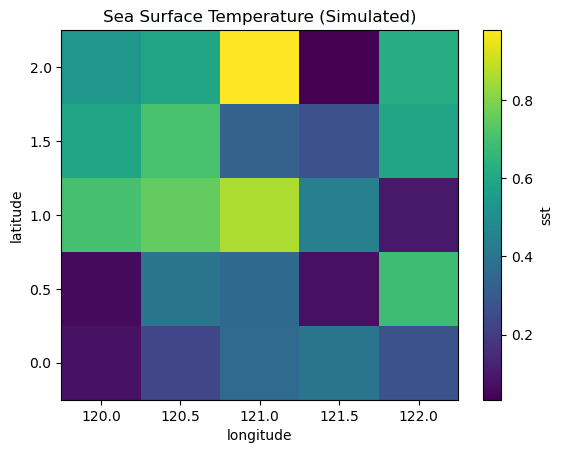

In [5]:
# Plot SST for first time step
slice_data.plot()
plt.title("Sea Surface Temperature (Simulated)")
plt.show()

In [6]:
"""
This is how data would be fetched from ERDDAP in a real scenario:

from erddapy import ERDDAP

e = ERDDAP(
    server="https://coastwatch.pfeg.noaa.gov/erddap",
    protocol="griddap"
)

e.dataset_id = "erdQMekm14day"
e.variables = ["sst"]

ds = e.to_xarray()

Note: This may fail due to network/firewall restrictions.
"""

'\nThis is how data would be fetched from ERDDAP in a real scenario:\n\nfrom erddapy import ERDDAP\n\ne = ERDDAP(\n    server="https://coastwatch.pfeg.noaa.gov/erddap",\n    protocol="griddap"\n)\n\ne.dataset_id = "erdQMekm14day"\ne.variables = ["sst"]\n\nds = e.to_xarray()\n\nNote: This may fail due to network/firewall restrictions.\n'

## Conclusion

This notebook demonstrates:

- How ERDDAP-style datasets can be handled using xarray
- Basic analysis and visualization workflows
- The structure expected for integration with erddapy

## Next Steps

- Integrate real ERDDAP datasets
- Improve error handling for network failures
- Extend support for metadata and coordinates

This work supports ongoing improvements in the erddapy xarray plugin.